# Étape 1 : Explorer les données

In [2]:
pip install polars

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

listings = pd.read_csv("../data/listings.csv.gz")
calendar = pd.read_csv("../data/calendar.csv.gz", nrows=100000)
reviews = pd.read_csv("../data/reviews.csv.gz")
neighbourhoods = pd.read_csv("../data/neighbourhoods.csv")


print(listings.shape)
print(calendar.shape)
print(reviews.shape)

(81853, 79)
(100000, 7)
(2228691, 6)


In [ ]:
print(listings.columns.tolist())
print(calendar.columns.tolist())
print(reviews.columns.tolist())


In [32]:
listings.head(5) # Cette table contient le listing des logements avec leurs caractéristiques
calendar.head(5) # catte table contient les informations sur les dates d'occupation, les prix, le nombre de jours et de nuits d'occupation .
reviews.head(5) # cette table contient les avis laissés par les voyageurs sur le logement.
neighbourhoods.head(5) 

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2719440,https://www.airbnb.com/rooms/2719440,20250912034503,2025-09-12,previous scrape,Nice flat close to Montparnasse,This beautiful apartment is very well located ...,"The neighborhood is very nice, feel free to sh...",https://a0.muscache.com/pictures/295786e7-116c...,13915159,...,4.94,4.86,4.73,7510702406383,f,1,1,0,0,0.57
1,2721397,https://www.airbnb.com/rooms/2721397,20250912034503,2025-09-12,previous scrape,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,https://a0.muscache.com/pictures/de55313f-9b4b...,13925876,...,4.95,4.91,4.85,7510400455677,f,1,1,0,0,0.66
2,2726092,https://www.airbnb.com/rooms/2726092,20250912034503,2025-09-12,previous scrape,Superbe 2 pièces idéalement placé,A stone's throw from Parc Monceau and the Arc ...,Quiet and residential area... Close to the Bat...,https://a0.muscache.com/pictures/6d6c4bc6-9473...,13612373,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
3,2726327,https://www.airbnb.com/rooms/2726327,20250912034503,2025-09-12,previous scrape,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,https://a0.muscache.com/pictures/6b569382-aed7...,7483725,...,4.97,4.92,4.67,7510901014972,f,1,1,0,0,0.72
4,2727929,https://www.airbnb.com/rooms/2727929,20250912034503,2025-09-12,previous scrape,Appartement d'architecte - Montmartre,"Our apartment, refurbished by an architect in ...",The apartment is in the heart of Paris's 18th ...,https://a0.muscache.com/pictures/miso/Hosting-...,13960346,...,5.00,4.57,5.00,7511808333770,f,1,1,0,0,0.25


# Étape 2 : Définir les questions métier

# Étape 3 : Concevoir le Data Warehouse

In [23]:
# Grain

# dim_property :
# Une ligne = un logement

# dim_host :
# Une ligne = un hôte

# dim_location :
# Une ligne = un quartier

# dim_date :
# Une ligne = une date

# fact_availability :
# Une ligne = un logement pour une date

# fact_reviews :
# Une ligne = un avis

listings.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [4]:
dim_property = listings[
    [
        'id',
        'name',
        'property_type',
        'room_type',
        'accommodates',
        'bedrooms',
        'beds',
        'neighbourhood_cleansed'
    ]
].copy()

#Pourquoi ?

#Parce que ce sont les attributs utilisés pour analyser :

#les types de logements
#la capacité d'accueil
#les quartiers
#les prix

In [5]:
dim_property = dim_property.rename(
    columns={'id': 'listing_id'}
)

In [6]:
#Dimension 2 : dim_host

#Une ligne = un hôte.
dim_host = listings[
    [
        'host_id',
        'host_name',
        'host_since',
        'host_is_superhost',
        'host_response_rate'
    ]
].drop_duplicates()

#Questions métier possibles :

#Les superhosts performent-ils mieux ?
#Les hôtes les plus réactifs génèrent-ils plus de revenus ?

In [7]:
# Dimension 3 : dim_location --- 1 ligne par localisation
dim_location = listings[
    [
        'neighbourhood_cleansed',
        'latitude',
        'longitude'
    ]
].copy()

In [8]:
# Supprimer les doublons sur la nouvelle dimension 
dim_location = dim_location.drop_duplicates()

In [9]:
# Vérification 
dim_location.head()

,neighbourhood_cleansed,latitude,longitude
0,Palais-Bourbon,48.849970,2.319740
1,Hôtel-de-Ville,48.852030,2.361760
2,Batignolles-Monceau,48.880040,2.306860
3,Opéra,48.882710,2.343550
4,Buttes-Montmartre,48.894917,2.336131


In [10]:
# Dimension 4 : dim_date
min_date = pd.to_datetime(reviews['date']).min()

max_date = max(
    pd.to_datetime(reviews['date']).max(),
    pd.to_datetime(calendar['date']).max()
)


In [11]:
# --- LA LIGNE À AJOUTER POUR CRÉER LE DATAFRAME ---
# Cela génère toutes les dates uniques entre le minimum et le maximum
dim_date = pd.DataFrame({'full_date': pd.date_range(start=min_date, end=max_date)})

In [12]:
dim_date['date_key'] = (
    dim_date['full_date']
    .dt.strftime('%Y%m%d')
    .astype(int)
)

dim_date['year'] = dim_date['full_date'].dt.year
dim_date['quarter'] = dim_date['full_date'].dt.quarter
dim_date['month'] = dim_date['full_date'].dt.month
dim_date['day'] = dim_date['full_date'].dt.day
dim_date['weekday'] = dim_date['full_date'].dt.day_name()

In [13]:
# Vérification
print(dim_date['full_date'].min())
print(dim_date['full_date'].max())

2010-01-26 00:00:00
2026-09-11 00:00:00


In [14]:
# créér une clé de date 
dim_date['date_key'] = (
    dim_date['full_date']
    .dt.strftime('%Y%m%d')
    .astype(int)
)

In [15]:
# Ajouter les attributs de date 
dim_date['year'] = dim_date['full_date'].dt.year
dim_date['month'] = dim_date['full_date'].dt.month
dim_date['quarter'] = dim_date['full_date'].dt.quarter
dim_date['day'] = dim_date['full_date'].dt.day
dim_date['weekday'] = dim_date['full_date'].dt.day_name()

In [16]:
# Vérification 
dim_date.head()

,full_date,date_key,year,quarter,month,day,weekday
0,2010-01-26,20100126,2010,1,1,26,Tuesday
1,2010-01-27,20100127,2010,1,1,27,Wednesday
2,2010-01-28,20100128,2010,1,1,28,Thursday
3,2010-01-29,20100129,2010,1,1,29,Friday
4,2010-01-30,20100130,2010,1,1,30,Saturday


In [17]:
calendar.shape
reviews.shape

(2228691, 6)

In [18]:
dim_date.shape

(6073, 7)

In [19]:
# Véfifions si les 4 dimensions sont réellement créées
print("dim_property :", dim_property.shape)
print("dim_host :", dim_host.shape)
print("dim_location :", dim_location.shape)
print("dim_date :", dim_date.shape)

dim_property : (81853, 8)
dim_host : (59587, 5)
dim_location : (77120, 3)
dim_date : (6073, 7)


In [20]:
for name, df in {
    "dim_property": dim_property,
    "dim_host": dim_host,
    "dim_location": dim_location,
    "dim_date": dim_date
}.items():
    print(f"\n{name}")
    print(df.shape)


dim_property
(81853, 8)

dim_host
(59587, 5)

dim_location
(77120, 3)

dim_date
(6073, 7)


In [21]:
#fact_availability
fact_availability = calendar.copy()

In [22]:
fact_availability.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,2719440,2025-09-12,f,NaN,NaN,2,7
1,2719440,2025-09-13,f,NaN,NaN,2,7
2,2719440,2025-09-14,f,NaN,NaN,2,7
3,2719440,2025-09-15,f,NaN,NaN,2,7
4,2719440,2025-09-16,f,NaN,NaN,2,7


In [23]:
# Ajouter l'indice d'occupation 
fact_availability['occupancy_flag'] = (
    fact_availability['available'] == 'f'
).astype(int)

#available = t → logement disponible → occupancy_flag = 0

#available = f → logement occupé → occupancy_flag = 1

In [24]:
# Vérification
fact_availability[
    ['available', 'occupancy_flag']
] #.head()

,available,occupancy_flag
0,f,1
1,f,1
2,f,1
3,f,1
4,f,1
...,...,...
99995,f,1
99996,f,1
99997,f,1
99998,f,1


In [25]:
# Fact_reviews
fact_reviews = reviews.copy()

In [26]:
### Ajouter une métrique
fact_reviews['review_count'] = 1 # Chaque ligne représentant déjà un avis.

In [27]:
fact_reviews['comment_length'] = (
    fact_reviews['comments']
    .fillna('')
    .str.len()
)

In [28]:
# Vérification 
fact_reviews[
    ['listing_id', 'review_count', 'comment_length']
].head()

,listing_id,review_count,comment_length
0,3109,1,39
1,3109,1,680
2,3109,1,148
3,3109,1,575
4,3109,1,272


In [29]:
# Vérifions les tables 
print(dim_property.shape)
print(dim_host.shape)
#print(dim_location.shape)
#print(dim_host.shape)

print(fact_availability.shape)
print(fact_reviews.shape)

(81853, 8)
(59587, 5)
(100000, 8)
(2228691, 8)


In [30]:
# Contrôle qualité
for name, df in {
    "dim_property": dim_property,
    "dim_host": dim_host,
    "fact_availability": fact_availability,
    "fact_reviews": fact_reviews
}.items():

    print(f"\n{name}")
    print("Rows :", len(df))
    print("Duplicates :", df.duplicated().sum())
    print("Nulls :")
    print(df.isna().sum().head())


dim_property
Rows : 81853
Duplicates : 0
Nulls :
listing_id       0
name             0
property_type    0
room_type        0
accommodates     0
dtype: int64

dim_host
Rows : 59587
Duplicates : 0
Nulls :
host_id                   0
host_name                19
host_since               19
host_is_superhost       678
host_response_rate    29514
dtype: int64

fact_availability
Rows : 100000
Duplicates : 0
Nulls :
listing_id             0
date                   0
available              0
price             100000
adjusted_price    100000
dtype: int64

fact_reviews
Rows : 2228691
Duplicates : 0
Nulls :
listing_id       0
id               0
date             0
reviewer_id      0
reviewer_name    3
dtype: int64


# Étape 4 : PostgreSQL

## Etape 1 : Crééer les clés techniques 

In [31]:
# Ajouter property_key
dim_property = dim_property.reset_index(drop=True)

dim_property['property_key'] = (
    dim_property.index + 1
)

In [32]:
# Puis réorganiser :
dim_property = dim_property[
    ['property_key'] +
    [c for c in dim_property.columns if c != 'property_key']
]

In [33]:
# Ajouter location_key
dim_location = dim_location.reset_index(drop=True)

dim_location['location_key'] = (
    dim_location.index + 1
)

In [34]:
# Ajouter host_key
dim_host = dim_host.reset_index(drop=True)

dim_host['host_key'] = (
    dim_host.index + 1
)

## Étape 2 : Construire fact_availability

In [35]:
# Ajouter property_key
fact_availability = fact_availability.merge(
    dim_property[
        ['listing_id', 'property_key']
    ],
    left_on='listing_id',
    right_on='listing_id',
    how='left'
)

In [36]:
# Ajouter date_key
fact_availability['date'] = pd.to_datetime(
    fact_availability['date']
)

In [37]:
# Puis réorganiser :
fact_availability = fact_availability.merge(
    dim_date[
        ['full_date', 'date_key']
    ],
    left_on='date',
    right_on='full_date',
    how='left'
)

In [38]:
# Garder seulement les colonnes utiles
fact_availability = fact_availability[
    [
        'property_key',
        'date_key',
        'occupancy_flag',
        'minimum_nights',
        'maximum_nights'
    ]
]

## Étape 3 : Construire fact_reviews

In [39]:
#Nettoyage préalable de la table 
fact_reviews = fact_reviews[
    [
        'listing_id',
        'date_key',
        'property_key',
        'review_count',
        'comment_length'
    ]
]

KeyError: "['date_key', 'property_key'] not in index"

In [ ]:
fact_reviews.head()

In [42]:
#print("property_key null :", fact_reviews['property_key'].isna().sum())
#print("date_key null :", fact_reviews['date_key'].isna().sum())

In [43]:
fact_reviews.columns.tolist()

['listing_id',
 'id',
 'date',
 'reviewer_id',
 'reviewer_name',
 'comments',
 'review_count',
 'comment_length']

In [44]:
# Ajouter property_key
fact_reviews = reviews.copy()

fact_reviews['review_count'] = 1

fact_reviews['comment_length'] = (
    fact_reviews['comments']
    .fillna('')
    .str.len()
)

fact_reviews['date'] = pd.to_datetime(fact_reviews['date'])

fact_reviews = fact_reviews.merge(
    dim_date[['full_date', 'date_key']],
    left_on='date',
    right_on='full_date',
    how='left'
)
fact_reviews = fact_reviews.merge(
    dim_property[['listing_id', 'property_key']],
    on='listing_id',
    how='left'
)

In [45]:
fact_reviews[['listing_id','property_key']].head()

,listing_id,property_key
0,3109,357
1,3109,357
2,3109,357
3,3109,357
4,3109,357


In [46]:
fact_reviews.columns.tolist()

['listing_id',
 'id',
 'date',
 'reviewer_id',
 'reviewer_name',
 'comments',
 'review_count',
 'comment_length',
 'full_date',
 'date_key',
 'property_key']

In [47]:
fact_reviews['property_key'].isna().sum()

0

In [48]:
fact_reviews['date_key'].isna().sum() # Problème d'intégrité référentielle corrigé

0

## Étape 4 : Data Quality & Validation

### 1. Vérifier les dimensions

In [49]:
# On va vérifer pour chaque dimension 
#
for name, df in {
    "dim_property": dim_property,
    "dim_host": dim_host,
    "dim_location": dim_location,
    "dim_date": dim_date
}.items():

    print(f"\n{name}")
    print("Rows:", len(df))
    print("Duplicates:", df.duplicated().sum())
    print("Nulls:")
    print(df.isna().sum().sort_values(ascending=False).head(10))


dim_property
Rows: 81853
Duplicates: 0
Nulls:
beds                      81853
bedrooms                  15427
property_key                  0
listing_id                    0
name                          0
property_type                 0
room_type                     0
accommodates                  0
neighbourhood_cleansed        0
dtype: int64

dim_host
Rows: 59587
Duplicates: 0
Nulls:
host_response_rate    29514
host_is_superhost       678
host_name                19
host_since               19
host_id                   0
host_key                  0
dtype: int64

dim_location
Rows: 77120
Duplicates: 0
Nulls:
neighbourhood_cleansed    0
latitude                  0
longitude                 0
location_key              0
dtype: int64

dim_date
Rows: 6073
Duplicates: 0
Nulls:
full_date    0
date_key     0
year         0
quarter      0
month        0
day          0
weekday      0
dtype: int64


### 2. Vérifier les tables de faits

In [50]:
print("fact_availability")
print("property_key null :", fact_availability['property_key'].isna().sum())
print("date_key null :", fact_availability['date_key'].isna().sum())

print("\nfact_reviews")
print("property_key null :", fact_reviews['property_key'].isna().sum())
print("date_key null :", fact_reviews['date_key'].isna().sum())

fact_availability
property_key null : 0
date_key null : 0

fact_reviews
property_key null : 0
date_key null : 0


In [51]:
fact_reviews.columns.tolist()

['listing_id',
 'id',
 'date',
 'reviewer_id',
 'reviewer_name',
 'comments',
 'review_count',
 'comment_length',
 'full_date',
 'date_key',
 'property_key']

### 3. Vérifier les clés orphelines

In [52]:
#fact_availability['property_key'].isna().sum()
#fact_reviews['property_key'].isna().sum()

### 4. Vérifier les dates

In [53]:
#fact_availability['date_key'].isna().sum() # Absence de valeurs null
fact_reviews['date_key'].isna().sum()

0

In [54]:
print("Calendar :")
print(calendar['date'].min())
print(calendar['date'].max())

print("\nReviews :")
print(reviews['date'].min())
print(reviews['date'].max())

Calendar :
2025-09-12
2026-09-11

Reviews :
2010-01-26
2025-09-15


# Étape 5 : Analyse métier / Business Analysis

### Nombre de logements par quartier

In [55]:
# Nombre de logements par quartier

(
    dim_property
    .groupby("neighbourhood_cleansed")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

neighbourhood_cleansed
Buttes-Montmartre      8685
Popincourt             7204
Vaugirard              6633
Entrepôt               5584
Batignolles-Monceau    5557
Passy                  5147
Buttes-Chaumont        4481
Ménilmontant           4438
Opéra                  3987
Temple                 3549
dtype: int64

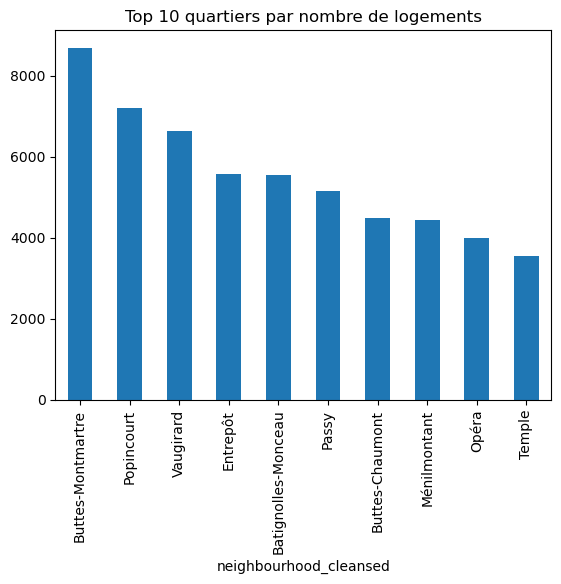

In [56]:
# Représentaion graphique du nombre de logement par quartier 
import matplotlib.pyplot as plt

(
    dim_property
    .groupby("neighbourhood_cleansed")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .plot(kind="bar")
)

plt.title("Top 10 quartiers par nombre de logements")
plt.show()

### Top 5 quartiers par nombre de logements

In [57]:
# Top 10 des quartiers par nombre de logements 
top_neighbourhoods = (
    dim_property
    .groupby('neighbourhood_cleansed')
    .size()
    .sort_values(ascending=False)
    .head(5)
)

top_neighbourhoods

neighbourhood_cleansed
Buttes-Montmartre      8685
Popincourt             7204
Vaugirard              6633
Entrepôt               5584
Batignolles-Monceau    5557
dtype: int64

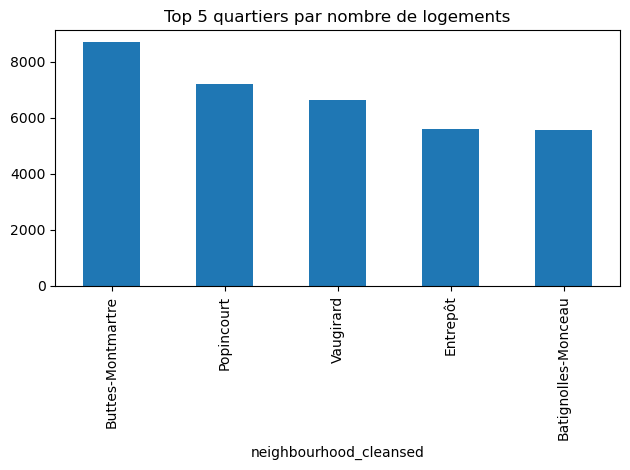

In [58]:
# Représentation graphique du Top 5 du nombre de logements 
import matplotlib.pyplot as plt

top_neighbourhoods.plot(kind='bar')

plt.title('Top 5 quartiers par nombre de logements')
plt.tight_layout()
plt.show()

### Évolution des avis 

In [59]:
# Évolution des avis
reviews_year = (
    fact_reviews
    .merge(
        dim_date[['date_key','year']],
        on='date_key'
    )
    .groupby('year')['review_count']
    .sum()
)

reviews_year

year
2010       164
2011       959
2012      3210
2013      8407
2014     20596
2015     45506
2016     68390
2017    100198
2018    141121
2019    172692
2020     61969
2021    116397
2022    265469
2023    365243
2024    447342
2025    411028
Name: review_count, dtype: int64

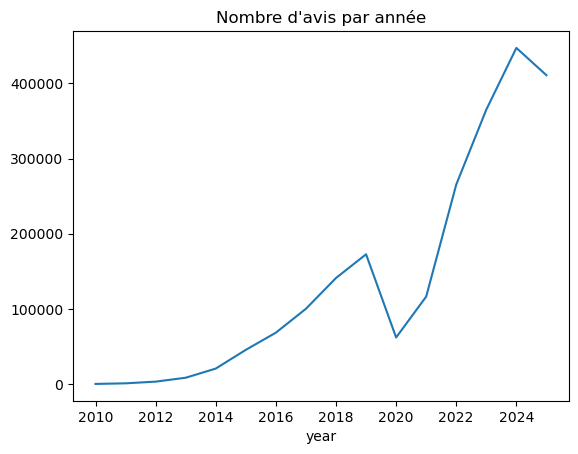

In [60]:
# Représenation graphique de l'évolution des avis
reviews_year.plot()
plt.title("Nombre d'avis par année")
plt.show()

### Occupation mensuelle

In [61]:
# Occupation mensuelle
calendar['month'] = pd.to_datetime(calendar['date']).dt.month

occupancy_month = (
    calendar
    .assign(
        occupancy_flag=(calendar['available'] == 'f').astype(int)
    )
    .groupby('month')['occupancy_flag']
    .mean()
    * 100
)

In [62]:
fact_availability.head(5)

,property_key,date_key,occupancy_flag,minimum_nights,maximum_nights
0,1,20250912,1,2,7
1,1,20250913,1,2,7
2,1,20250914,1,2,7
3,1,20250915,1,2,7
4,1,20250916,1,2,7


### Longueur moyenne des commentaires

In [63]:
# Longueur moyenne des commentaires
fact_reviews['comment_length'].mean()

256.41480941054635

### Top 20 logements les plus commentés

In [64]:
# Top 20 logements les plus commentés
top_reviews = (
    fact_reviews
    .groupby('property_key')['review_count']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print(top_reviews)

# Question métier :

# Quels logements génèrent le plus d'engagement ?

property_key
12600    4040
18056    2616
25373    2319
22338    2106
20950    1795
1190     1331
20773    1265
24626    1232
7080     1171
1537     1156
24382    1146
20852    1010
2404      995
453       948
5084      943
73634     940
22450     935
24354     921
69745     892
4393      892
Name: review_count, dtype: int64


### 🏠 Répartition des types de logements

property_type
Entire rental unit                   67797
Private room in rental unit           5506
Entire condo                          2279
Room in hotel                         1377
Room in boutique hotel                1074
Entire loft                            890
Private room in bed and breakfast      552
Entire home                            529
Private room in condo                  316
Entire serviced apartment              278
dtype: int64


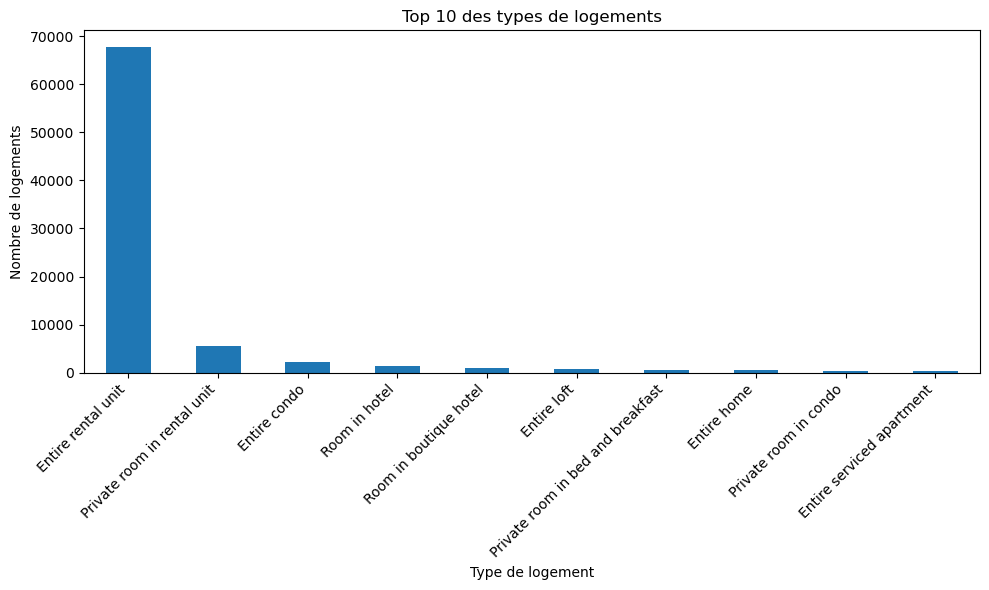

In [65]:
import matplotlib.pyplot as plt

property_distribution = (
    dim_property
    .groupby("property_type")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(property_distribution)

plt.figure(figsize=(10,6))
property_distribution.plot(kind="bar")
plt.title("Top 10 des types de logements")
plt.xlabel("Type de logement")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 📅 Taux d'occupation mensuel

month
1     70.06
2     67.40
3     70.16
4     71.08
5     69.87
6     73.65
7     71.87
8     72.25
9     80.75
10    79.13
11    73.44
12    72.46
Name: occupancy_flag, dtype: float64


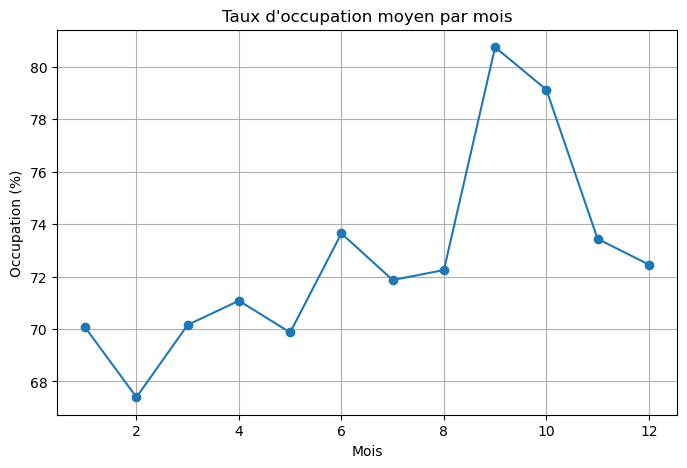

In [66]:
fact_availability["month"] = (
    fact_availability["date_key"] // 100
) % 100

occupancy_month = (
    fact_availability
    .groupby("month")["occupancy_flag"]
    .mean()
    .mul(100)
    .round(2)
)

print(occupancy_month)

plt.figure(figsize=(8,5))
occupancy_month.plot(marker="o")
plt.title("Taux d'occupation moyen par mois")
plt.xlabel("Mois")
plt.ylabel("Occupation (%)")
plt.grid(True)
plt.show()

### ⭐ Impact du statut Superhost

In [67]:
# Ajouter host_id dans la dim_property
dim_property = dim_property.merge(
    listings[['id', 'host_id']],
    left_on='listing_id',
    right_on='id',
    how='left'
)

In [68]:
dim_property = dim_property.drop(columns='id')

In [69]:
dim_property.columns

Index(['property_key', 'listing_id', 'name', 'property_type', 'room_type',
       'accommodates', 'bedrooms', 'beds', 'neighbourhood_cleansed',
       'host_id'],
      dtype='object')

In [70]:
# Ajouter host_key
dim_property = dim_property.merge(
    dim_host[['host_id', 'host_key']],
    on='host_id',
    how='left'
)

In [71]:
dim_property[['listing_id', 'host_id', 'host_key']].head()

,listing_id,host_id,host_key
0,2719440,13915159,1
1,2721397,13925876,2
2,2726092,13612373,3
3,2726327,7483725,4
4,2727929,13960346,5


In [72]:
# Calcul du KPI Super Host
superhost_analysis = (
    dim_property
    .merge(
        dim_host[['host_key', 'host_is_superhost']],
        on='host_key',
        how='left'
    )
    .groupby('host_is_superhost')
    .size()
    .rename('Nombre de logements')
)

print(superhost_analysis)

host_is_superhost
f    62568
t    16972
Name: Nombre de logements, dtype: int64


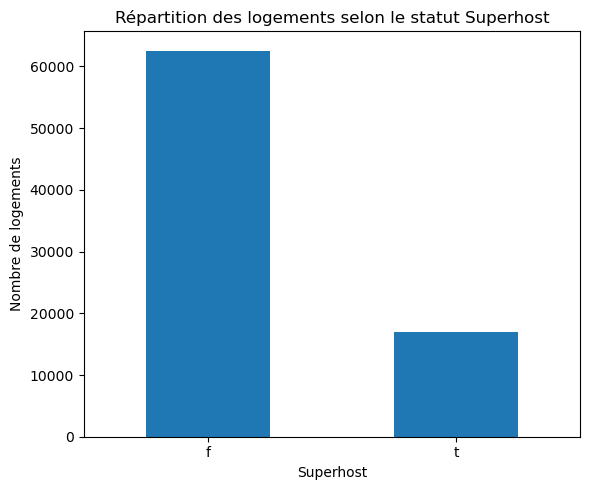

In [73]:
# Représntation graphique du super host 
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

superhost_analysis.plot(kind='bar')

plt.title("Répartition des logements selon le statut Superhost")
plt.xlabel("Superhost")
plt.ylabel("Nombre de logements")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

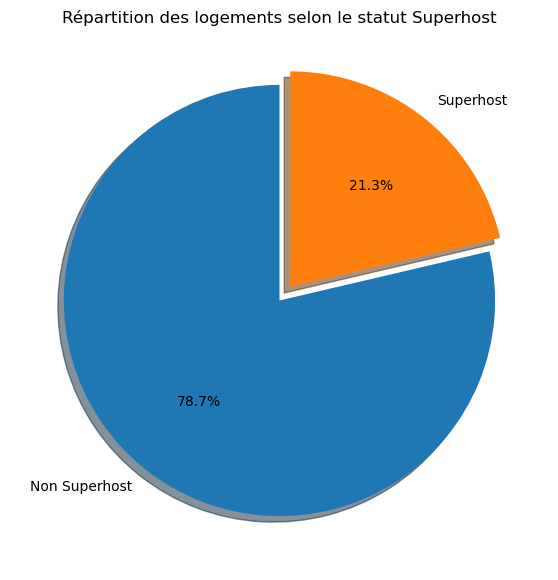

In [74]:
# Renommer les catégories
superhost_analysis.index = ['Non Superhost', 'Superhost']

# Camembert
plt.figure(figsize=(7,7))

plt.pie(
    superhost_analysis,
    labels=superhost_analysis.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.08),
    shadow=True
)

plt.title("Répartition des logements selon le statut Superhost")

plt.show()

# Etape 5 : Exporter les tables 

In [75]:
import os

# Créer le dossier warehouse s'il n'existe pas
os.makedirs("../warehouse", exist_ok=True)

# Export des dimensions
dim_property.to_csv("../warehouse/dim_property.csv", index=False)
dim_host.to_csv("../warehouse/dim_host.csv", index=False)
dim_location.to_csv("../warehouse/dim_location.csv", index=False)
dim_date.to_csv("../warehouse/dim_date.csv", index=False)

# Export des tables de faits
fact_reviews.to_csv("../warehouse/fact_reviews.csv", index=False)
fact_availability.to_csv("../warehouse/fact_availability.csv", index=False)

print("✅ Toutes les tables ont été exportées avec succès !")

✅ Toutes les tables ont été exportées avec succès !


# Etape 6 : Contrôler les exports

In [76]:
print(dim_property.shape)
print(dim_host.shape)
print(dim_location.shape)
print(dim_date.shape)
print(fact_reviews.shape)
print(fact_availability.shape)

(81853, 11)
(59587, 6)
(77120, 4)
(6073, 7)
(2228691, 11)
(100000, 6)


In [78]:
dim_host.head()

,host_id,host_name,host_since,host_is_superhost,host_response_rate,host_key
0,13915159,Thibaut,2014-04-05,f,NaN,1
1,13925876,Cecilie,2014-04-05,t,100%,2
2,13612373,Clemence,2014-03-27,f,NaN,3
3,7483725,Hélène,2013-07-14,f,100%,4
4,13960346,Paul,2014-04-06,f,100%,5


# Étape 7 : PostgreSQL

# Chargement du Data Warehouse dans SQLite

In [80]:
import sqlite3
import os

# Création du dossier si nécessaire
os.makedirs("../warehouse", exist_ok=True)

# Création de la base SQLite
conn = sqlite3.connect("../warehouse/airbnb_dw.db")

print("Base SQLite créée avec succès !")

Base SQLite créée avec succès !


In [81]:
# Charger les dimensions
dim_property.to_sql(
    "dim_property",
    conn,
    if_exists="replace",
    index=False
)

dim_host.to_sql(
    "dim_host",
    conn,
    if_exists="replace",
    index=False
)

dim_location.to_sql(
    "dim_location",
    conn,
    if_exists="replace",
    index=False
)

dim_date.to_sql(
    "dim_date",
    conn,
    if_exists="replace",
    index=False
)

6073

In [82]:
# Charger les tables de faits
fact_reviews.to_sql(
    "fact_reviews",
    conn,
    if_exists="replace",
    index=False
)

fact_availability.to_sql(
    "fact_availability",
    conn,
    if_exists="replace",
    index=False
)

100000

In [83]:
# Vérifier que tout est chargé 
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,dim_property
1,dim_host
2,dim_location
3,dim_date
4,fact_reviews
5,fact_availability


In [84]:
# Requete sql 1 : nb logements
query = """
SELECT
    property_type,
    COUNT(*) AS nb_logements
FROM dim_property
GROUP BY property_type
ORDER BY nb_logements DESC;
"""

result = pd.read_sql(query, conn)

result

,property_type,nb_logements
0,Entire rental unit,67797
1,Private room in rental unit,5506
2,Entire condo,2279
3,Room in hotel,1377
4,Room in boutique hotel,1074
...,...,...
56,Earthen home,1
57,Dome,1
58,Cave,1
59,Camper/RV,1


In [87]:
# Requête 2 — Évolution annuelle des avis ⭐⭐⭐⭐
# Comment le nombre d'avis a-t-il évolué au fil des années ?
query = """
SELECT
    d.year,
    SUM(f.review_count) AS total_reviews
FROM fact_reviews f
JOIN dim_date d
    ON f.date_key = d.date_key
GROUP BY d.year
ORDER BY d.year;
"""

reviews_by_year = pd.read_sql(query, conn)

print(reviews_by_year)

    year  total_reviews
0   2010            164
1   2011            959
2   2012           3210
3   2013           8407
4   2014          20596
5   2015          45506
6   2016          68390
7   2017         100198
8   2018         141121
9   2019         172692
10  2020          61969
11  2021         116397
12  2022         265469
13  2023         365243
14  2024         447342
15  2025         411028


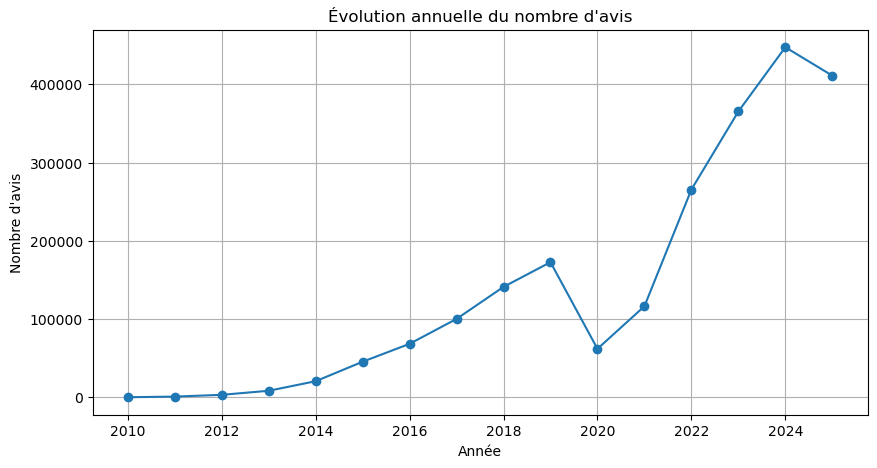

In [88]:
# Représentation graphique 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    reviews_by_year["year"],
    reviews_by_year["total_reviews"],
    marker="o"
)

plt.title("Évolution annuelle du nombre d'avis")
plt.xlabel("Année")
plt.ylabel("Nombre d'avis")

plt.grid(True)

plt.show()

In [89]:
# Requête 2 — Taux d'occupation par quartier ⭐⭐⭐⭐⭐
query = """
SELECT
    p.neighbourhood_cleansed,
    ROUND(AVG(f.occupancy_flag) * 100,2) AS occupancy_rate
FROM fact_availability f
JOIN dim_property p
    ON f.property_key = p.property_key
GROUP BY p.neighbourhood_cleansed
ORDER BY occupancy_rate DESC;
"""

occupancy = pd.read_sql(query, conn)

occupancy.head(10)

,neighbourhood_cleansed,occupancy_rate
0,Entrepôt,85.74
1,Gobelins,84.38
2,Panthéon,80.78
3,Ménilmontant,78.64
4,Buttes-Montmartre,75.88
5,Observatoire,75.01
6,Popincourt,74.86
7,Bourse,73.93
8,Vaugirard,73.08
9,Batignolles-Monceau,72.35


In [95]:
# Quels quartiers présentent un taux d'ocupation inférieur à 50 %
query = """
WITH neighbourhood_stats AS (
    SELECT
        p.neighbourhood_cleansed,
        ROUND(AVG(f.occupancy_flag) * 100,2) AS occupancy_rate
    FROM fact_availability f
    JOIN dim_property p
        ON f.property_key = p.property_key
    GROUP BY p.neighbourhood_cleansed
)

SELECT *
FROM neighbourhood_stats
WHERE occupancy_rate  <= 50
ORDER BY occupancy_rate DESC;
"""

high_occupancy = pd.read_sql(query, conn)

high_occupancy

,neighbourhood_cleansed,occupancy_rate


In [106]:
# Nombrde logement par type
query = """
WITH room_type as (
SELECT room_type, COUNT(*) as nb_logements
FROM dim_property
GROUP BY room_type
ORDER BY COUNT(*)
  )
  SELECT * FROM room_type WHERE nb_logements >= 200
;
"""

result = pd.read_sql(query, conn)

result

,room_type,nb_logements
0,Hotel room,664
1,Private room,8727
2,Entire home/apt,72297


In [109]:
# Export des fichiers 
listings.to_csv("../Warehouse/listings_clean.csv", index=False)
reviews.to_csv("../Warehouse/reviews_clean.csv", index=False)
calendar.to_csv("../Warehouse/calendar_clean.csv", index=False)